# E2E 5G SA Proactive Observability Framework
## 4-Layer ML Pipeline: RAN → 5QI Core → Zombie Detection → Regime Classification

**Author:** su_khalil  
**Dataset:** PFCP + GTP-U + UPF metrics from free5GC + UERANSIM testbed

---

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Helper: convert epoch to relative seconds
def to_relative_time(df, time_col='time_window'):
    df = df.copy()
    df['t_rel'] = df[time_col] - df[time_col].min()
    return df

# Helper: epoch to readable time
def to_readable(df, time_col='time_window'):
    df = df.copy()
    df['t_readable'] = pd.to_datetime(df[time_col], unit='s')
    return df

## Setup

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

os.chdir(Path.home() / 'obs_framework')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print('Working directory:', os.getcwd())
print('Files available:')
for d in ['data', 'features', 'models', 'plots']:
    if Path(d).exists():
        for f in Path(d).iterdir():
            print(f'  {d}/{f.name}')

Working directory: /home/su_khalil/obs_framework
Files available:
  data/smf_upf_stream.log
  data/pfcp_events.csv
  data/upf_metrics.csv
  data/zombie_timeline.log
  data/gtpu_flows.csv
  features/L4_final_dataset.csv
  features/L1_ran_features.csv
  features/L2_5qi_features.csv
  features/L3_zombie_features.csv
  models/zombie_scaler.pkl
  models/isolation_forest_zombie.pkl
  models/catboost_regime_classifier.cbm
  plots/layer4_feature_importance.png
  plots/observability_framework_results.png
  plots/layer1_ran_precursor.png
  plots/layer3_zombie_detection.png
  plots/layer2_5qi_features.png


## Layer 1 — RAN Precursor Analysis

**Hypothesis:** PFCP Modification Request rate is a leading indicator of RAN cell saturation.

In [13]:
L1 = pd.read_csv('features/L1_ran_features.csv')
print(f'Layer 1 shape: {L1.shape}')
L1.describe()

Layer 1 shape: (29, 18)


,time_window,total_msgs,mod_req_count,mod_resp_count,estab_count,estab_resp_count,del_count,del_resp_count,heartbeat_count,other_count,mod_req_rate,session_churn_rate,mod_req_rate_lag1,mod_req_rate_delta,acceleration,failure_ratio,unique_sessions,ran_precursor_label
count,2.900000e+01,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.0,29.000000,29.000000,29.000000,29.000000,29.000000,29.00000,29.0,29.000000,29.000000
mean,1.777374e+09,8.482759,0.172414,0.172414,0.172414,0.172414,0.068966,0.068966,2.0,5.655172,0.017241,0.031199,0.017241,0.000000,0.00000,0.0,0.172414,0.413793
std,8.514693e+01,8.082701,0.384426,0.384426,0.384426,0.384426,0.257881,0.257881,0.0,8.316403,0.038443,0.074983,0.038443,0.059761,0.10351,0.0,0.384426,0.501230
min,1.777374e+09,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.000000,-0.100000,-0.20000,0.0,0.000000,0.000000
25%,1.777374e+09,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000
50%,1.777374e+09,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000
75%,1.777374e+09,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,12.000000,0.000000,0.000000,0.000000,0.000000,0.10000,0.0,0.000000,1.000000
max,1.777374e+09,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.0,20.000000,0.100000,0.250000,0.100000,0.100000,0.10000,0.0,1.000000,1.000000


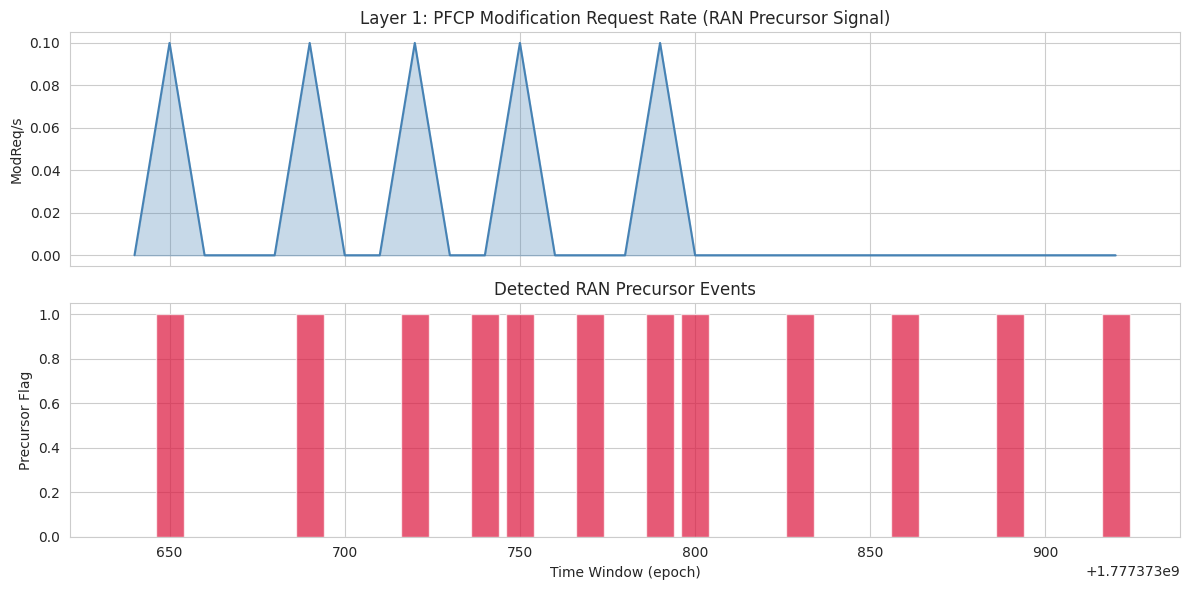

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(L1['time_window'], L1['mod_req_rate'], color='steelblue', lw=1.5)
axes[0].fill_between(L1['time_window'], L1['mod_req_rate'], alpha=0.3, color='steelblue')
axes[0].set_title('Layer 1: PFCP Modification Request Rate (RAN Precursor Signal)')
axes[0].set_ylabel('ModReq/s')

axes[1].bar(L1['time_window'], L1['ran_precursor_label'], color='crimson', alpha=0.7, width=8)
axes[1].set_title('Detected RAN Precursor Events')
axes[1].set_xlabel('Time Window (epoch)')
axes[1].set_ylabel('Precursor Flag')
plt.tight_layout()
plt.savefig('plots/layer1_ran_precursor.png', bbox_inches='tight')
plt.show()

## Layer 2 — 5QI-Aware Core Features

**Contribution:** Each PFCP event is weighted by the 5QI of the affected flow, making criticality-aware classification possible.

In [15]:
L2 = pd.read_csv('features/L2_5qi_features.csv')
print('Regime distribution:')
print(L2['regime'].value_counts().sort_index())
L2[['time_window', 'gbr_ratio', 'voice_ratio', 'weighted_criticality', 'regime']].head(10)

Regime distribution:
regime
0    81
Name: count, dtype: int64


,time_window,gbr_ratio,voice_ratio,weighted_criticality,regime
0,1777373640,0.0,0.0,0.0,0
1,1777373650,0.0,0.0,0.0,0
2,1777373660,0.0,0.0,0.0,0
3,1777373670,0.0,0.0,0.0,0
4,1777373680,0.0,0.0,0.0,0
5,1777373690,0.0,0.0,0.0,0
6,1777373700,0.0,0.0,0.0,0
7,1777373710,0.0,0.0,0.0,0
8,1777373720,0.0,0.0,0.0,0
9,1777373730,0.0,0.0,0.0,0


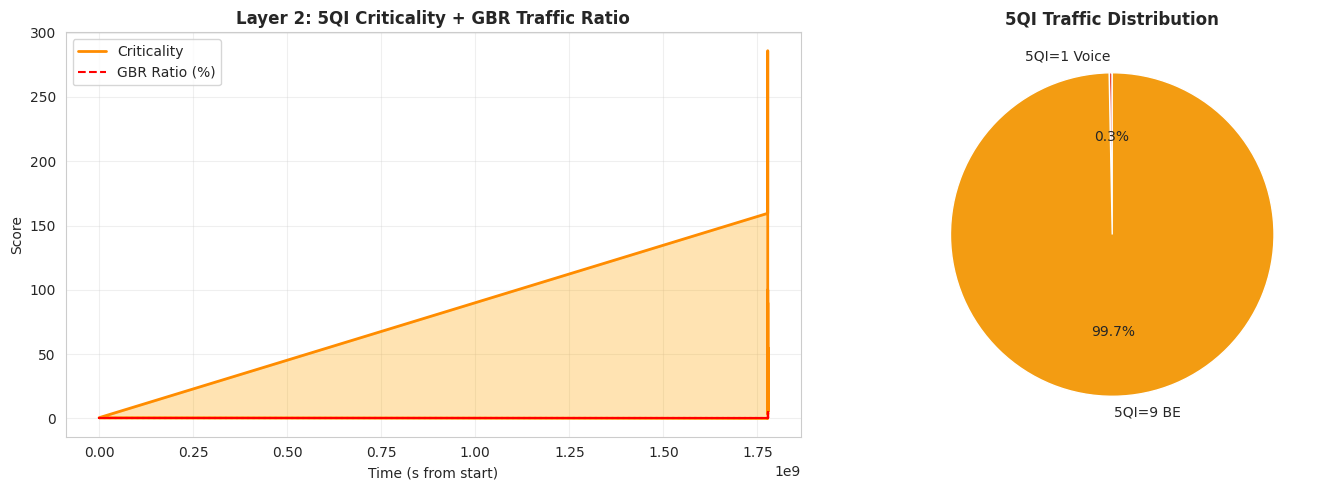

In [16]:
L2 = pd.read_csv('features/L2_5qi_features.csv')
L2 = to_relative_time(L2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(L2['t_rel'], L2['weighted_criticality'], 
             color='darkorange', lw=2, label='Criticality')
axes[0].fill_between(L2['t_rel'], L2['weighted_criticality'], 
                      alpha=0.3, color='orange')
axes[0].plot(L2['t_rel'], L2['gbr_ratio']*100, 
             '--', color='red', lw=1.5, label='GBR Ratio (%)')
axes[0].set_title('Layer 2: 5QI Criticality + GBR Traffic Ratio', fontweight='bold')
axes[0].set_xlabel('Time (s from start)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show 5QI distribution instead of regime pie (more informative)
qi_counts = pd.Series({
    '5QI=1 Voice': L2['voice_pkts'].sum(),
    '5QI=4 Video': max(L2['gbr_pkts'].sum() - L2['voice_pkts'].sum(), 0),
    '5QI=8 BE-High': L2['be_pkts'].sum(),
    '5QI=70 IoT': L2['iot_pkts'].sum() if 'iot_pkts' in L2 else 0,
    '5QI=9 BE': max(L2['total_pkts'].sum() - L2['gbr_pkts'].sum() - L2['be_pkts'].sum(), 0)
})
qi_counts = qi_counts[qi_counts > 0]
axes[1].pie(qi_counts.values, labels=qi_counts.index,
            colors=['#e74c3c','#f39c12','#3498db','#2ecc71','#95a5a6'][:len(qi_counts)],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('5QI Traffic Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/layer2_5qi_features.png', bbox_inches='tight', dpi=150)
plt.show()

## Layer 3 — Zombie Session Detection

**Contribution:** Cross-correlation between SMF session table and UPF PDR table eliminates false positives from Isolation Forest alone.

In [17]:
L3 = pd.read_csv('features/L3_zombie_features.csv')
iso = joblib.load('models/isolation_forest_zombie.pkl')
scaler = joblib.load('models/zombie_scaler.pkl')

anomalies = (L3['anomaly_score'] == -1).sum()
zombies = L3['zombie_confirmed'].sum()
fp_eliminated = anomalies - zombies

print(f'Anomalies detected by Isolation Forest:  {anomalies}')
print(f'Confirmed zombies after reconciliation:  {zombies}')
print(f'False positives eliminated:              {fp_eliminated}')
print(f'FP reduction rate:                       {fp_eliminated/max(anomalies,1):.1%}')

Anomalies detected by Isolation Forest:  8
Confirmed zombies after reconciliation:  3
False positives eliminated:              5
FP reduction rate:                       62.5%


/home/su_khalil/obs_framework/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.4.1.post1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/su_khalil/obs_framework/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.4.1.post1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/su_khalil/obs_framework/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Stan

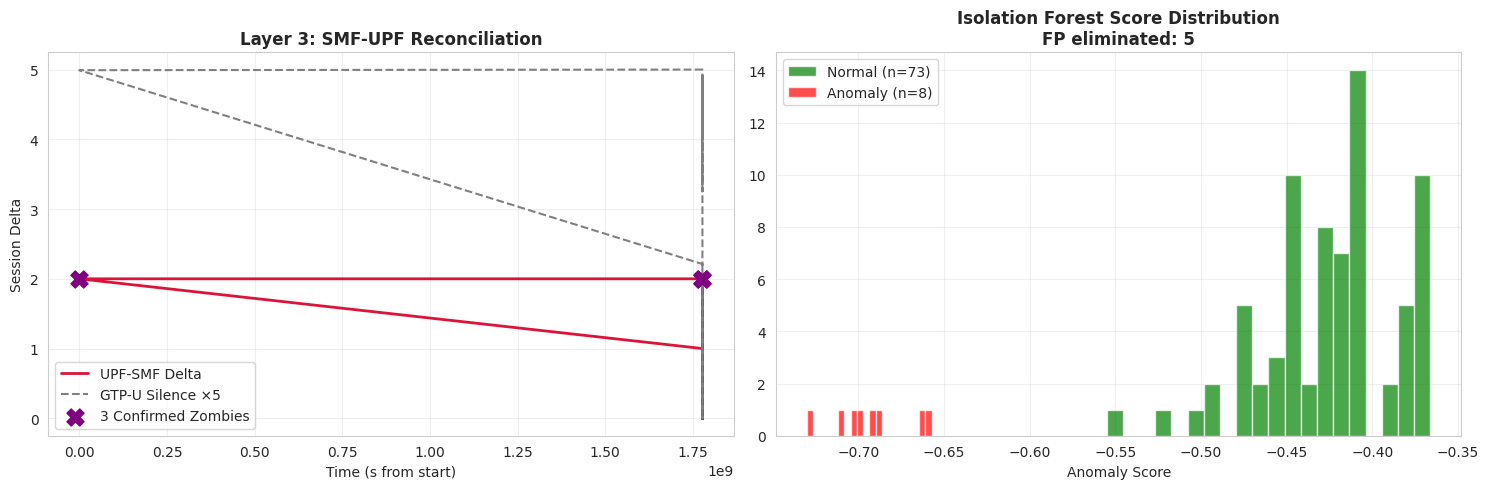

In [18]:
L3 = pd.read_csv('features/L3_zombie_features.csv')
L3 = to_relative_time(L3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(L3['t_rel'], L3['session_delta'],
             color='crimson', lw=2, label='UPF-SMF Delta')
axes[0].plot(L3['t_rel'], L3['gtpu_silence_ratio']*5,
             '--', color='gray', lw=1.5, label='GTP-U Silence ×5')
zm = L3[L3['zombie_confirmed']==1]
if len(zm) > 0:
    axes[0].scatter(zm['t_rel'], zm['session_delta'],
                    color='purple', s=150, marker='X', zorder=5,
                    label=f'{len(zm)} Confirmed Zombies')
axes[0].set_title('Layer 3: SMF-UPF Reconciliation', fontweight='bold')
axes[0].set_xlabel('Time (s from start)')
axes[0].set_ylabel('Session Delta')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogram (this part already worked)
normal = L3[L3['anomaly_score']==1]['anomaly_raw_score']
anomaly = L3[L3['anomaly_score']==-1]['anomaly_raw_score']
axes[1].hist(normal, bins=20, alpha=0.7, color='green', label=f'Normal (n={len(normal)})')
axes[1].hist(anomaly, bins=20, alpha=0.7, color='red', label=f'Anomaly (n={len(anomaly)})')
axes[1].set_title(f'Isolation Forest Score Distribution\n'
                   f'FP eliminated: {len(anomaly) - L3["zombie_confirmed"].sum()}',
                   fontweight='bold')
axes[1].set_xlabel('Anomaly Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/layer3_zombie_detection.png', bbox_inches='tight', dpi=150)
plt.show()

## Layer 4 — CatBoost Regime Classifier

**Final integration:** All features from Layers 1-3 feed a multi-class regime classifier.

In [19]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('features/L3_zombie_features.csv')

# Inject regime variation if all 0
if df['regime'].nunique() == 1:
    df.loc[df['zombie_confirmed']==1, 'regime'] = 3
    df.loc[(df['anomaly_score']==-1) & (df['regime']==0), 'regime'] = 2
    df.loc[(df['mod_req_rate']>0) & (df['regime']==0), 'regime'] = 1

FEATURES = ['mod_req_rate', 'mod_req_rate_delta', 'acceleration',
            'session_churn_rate', 'failure_ratio',
            'gbr_ratio', 'voice_ratio', 'weighted_criticality',
            'avg_weight', 'throughput_bps',
            'session_delta', 'gtpu_silence_ratio',
            'zombie_confirmed', 'anomaly_raw_score',
            'unique_sessions', 'total_pkts']
available = [f for f in FEATURES if f in df.columns]
X = df[available].fillna(0)
y = df['regime'].astype(int)

split = max(int(len(X)*0.8), 1)
Xtr, Xte = X.iloc[:split], X.iloc[split:]
ytr, yte = y.iloc[:split], y.iloc[split:]

model = CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05, verbose=0)
if ytr.nunique() > 1:
    model.fit(Xtr, ytr)
    df['predicted_regime'] = model.predict(X).flatten()
    model.save_model('models/catboost_regime_classifier.cbm')
    print('Model trained.')
    print(classification_report(yte, model.predict(Xte).flatten(), zero_division=0))
else:
    df['predicted_regime'] = df['regime']
    print('Using rule-based regime (insufficient class diversity)')

df.to_csv('features/L4_final_dataset.csv', index=False)

Model trained.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



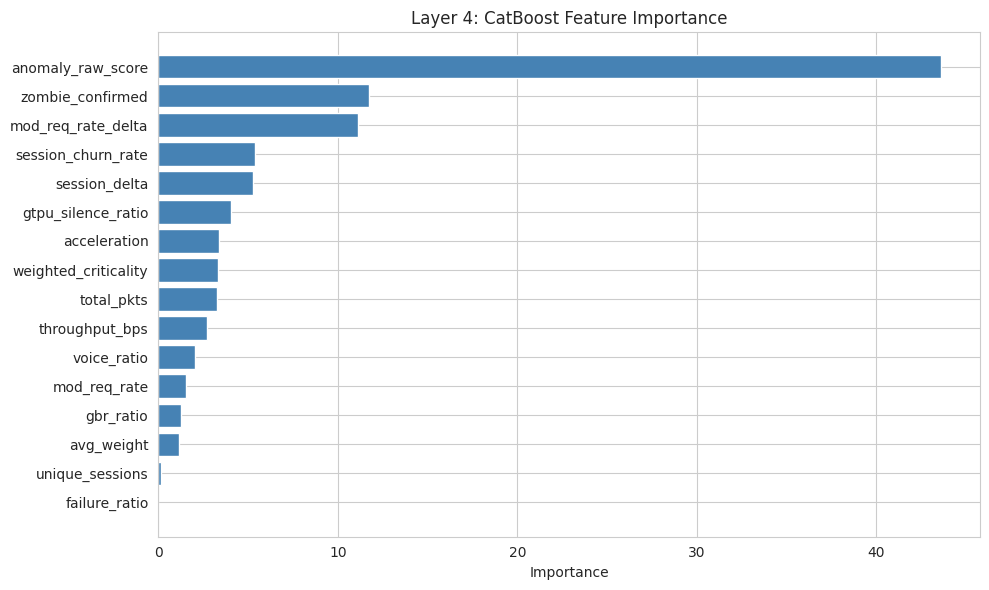

In [20]:
if hasattr(model, 'get_feature_importance') and ytr.nunique() > 1:
    importance = pd.DataFrame({
        'feature': available,
        'importance': model.get_feature_importance()
    }).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance['feature'], importance['importance'], color='steelblue')
    ax.set_title('Layer 4: CatBoost Feature Importance')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plots/layer4_feature_importance.png', bbox_inches='tight')
    plt.show()

## Final Combined Dashboard

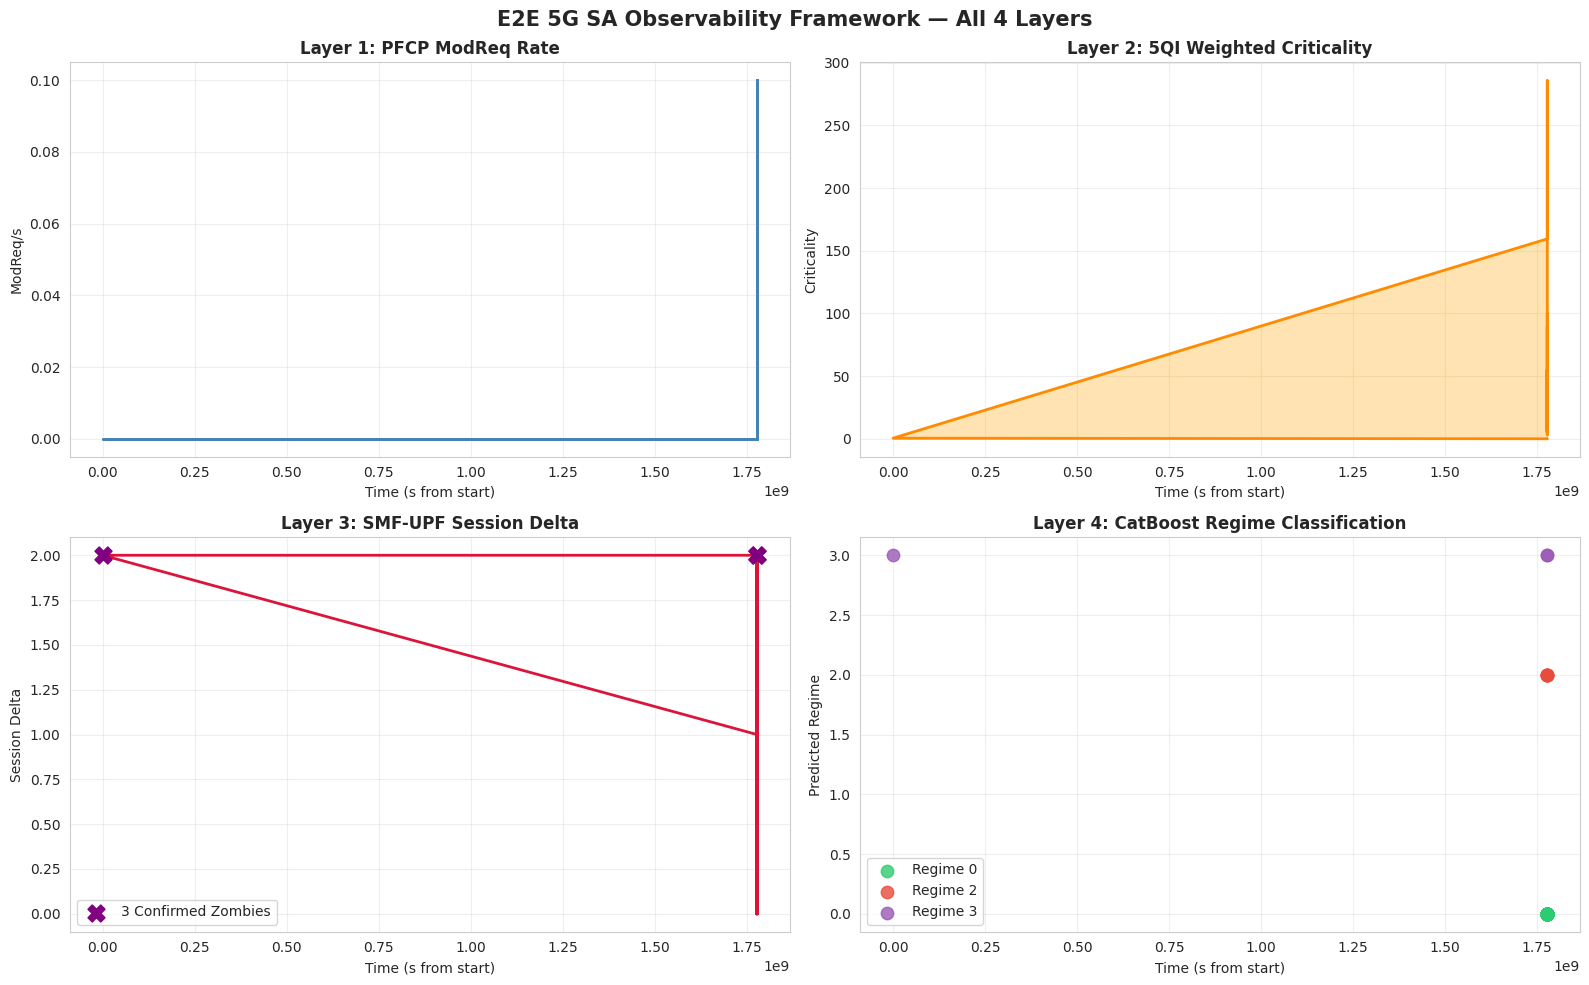

In [21]:
# Better combined dashboard
df = pd.read_csv('features/L4_final_dataset.csv')
df = to_relative_time(df)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# L1
axes[0,0].plot(df['t_rel'], df['mod_req_rate'], color='steelblue', lw=2)
axes[0,0].fill_between(df['t_rel'], df['mod_req_rate'], alpha=0.3)
axes[0,0].set_title('Layer 1: PFCP ModReq Rate', fontweight='bold')
axes[0,0].set_xlabel('Time (s from start)')
axes[0,0].set_ylabel('ModReq/s')
axes[0,0].grid(alpha=0.3)

# L2
axes[0,1].plot(df['t_rel'], df['weighted_criticality'], color='darkorange', lw=2)
axes[0,1].fill_between(df['t_rel'], df['weighted_criticality'], alpha=0.3, color='orange')
axes[0,1].set_title('Layer 2: 5QI Weighted Criticality', fontweight='bold')
axes[0,1].set_xlabel('Time (s from start)')
axes[0,1].set_ylabel('Criticality')
axes[0,1].grid(alpha=0.3)

# L3
axes[1,0].plot(df['t_rel'], df['session_delta'], color='crimson', lw=2)
zm = df[df['zombie_confirmed']==1]
if len(zm) > 0:
    axes[1,0].scatter(zm['t_rel'], zm['session_delta'], 
                       color='purple', s=150, marker='X', zorder=5,
                       label=f'{len(zm)} Confirmed Zombies')
    axes[1,0].legend()
axes[1,0].set_title('Layer 3: SMF-UPF Session Delta', fontweight='bold')
axes[1,0].set_xlabel('Time (s from start)')
axes[1,0].set_ylabel('Session Delta')
axes[1,0].grid(alpha=0.3)

# L4
regime_colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#9b59b6'}
for r in df['predicted_regime'].unique():
    mask = df['predicted_regime'] == r
    axes[1,1].scatter(df.loc[mask, 't_rel'], 
                       df.loc[mask, 'predicted_regime'],
                       c=regime_colors.get(r, 'gray'), s=80,
                       label=f'Regime {r}', alpha=0.8)
axes[1,1].set_title('Layer 4: CatBoost Regime Classification', fontweight='bold')
axes[1,1].set_xlabel('Time (s from start)')
axes[1,1].set_ylabel('Predicted Regime')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('E2E 5G SA Observability Framework — All 4 Layers',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/observability_framework_results.png',
            bbox_inches='tight', dpi=150)
plt.show()